# Perceived Effectiveness Index — candidate measure EDA (thesis-scoped)

**Purpose:** decide the best composite operationalisation of *perceived effectiveness* for the
thesis's pooled T1–T3 prediction models (T4 excluded). This notebook is separate from the
`icmi_paper/` HMM-state analyses — it only concerns target/label construction.

**Candidate items (user-selected, per task):**

| Task | Generic anchor(s) | Task-specific anchor |
|---|---|---|
| T1 | `team_coordination` | `decision_confidence` (proxy for satisfaction — T1 has no `satisfaction` item) |
| T2 | *(no `team_coordination` in T2 — verify below)* | `cooperative` (coop-vs-competitive framing), `manipcheck_t2` (mutual-benefit check), `satisfaction` |
| T3 | `team_coordination`, `satisfaction` | `idea_quality` |

`voice_inclusion` is **excluded** from the composite (per discussion — it measures inclusion/participation,
not perceived effectiveness of the outcome/process) but is kept as a separate secondary target elsewhere.

**Data source:** `metadata/extracted stimuli answers_verified/` — reconciled, de-duplicated post-block
responses for groups grp-07…grp-16 (the 10 groups with `status == "ok"` in `reconciliation_audit.tsv`).

**What this notebook checks:**
1. Which items actually exist per task (don't trust hardcoded lists — verify empirically)
2. Distributions / missingness per candidate item per task
3. Correlations among candidate items within each task
4. Internal consistency (Cronbach's α) of candidate composites per task
5. A few alternative composite formulations, compared
6. Whether the chosen composite is balanced across tasks (before/after within-task z-scoring)
7. Export a final scored table


## 1. Load and prepare data

Load every reconciled post-block answers file, concatenate to one long dataframe
(`wall_clock, lsl_clock, task, phase, response_type, participant, device_id, item_key, item_value`),
coerce `item_value` to numeric, and restrict to `response_type == "postblock"` and `task in {T1, T2, T3}`.


In [3]:
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", font_scale=1.0)
%matplotlib inline

REPO_ROOT = Path.cwd() if (Path.cwd() / "icmi_paper").exists() else Path.cwd().parent
STIM_DIR = REPO_ROOT / "metadata" / "extracted stimuli answers_verified"
TASKS = ["T1", "T2", "T3"]  # T4 excluded from thesis models
GRPRE = re.compile(r"grp[_-]([A-Za-z0-9]+)", re.IGNORECASE)

assert STIM_DIR.exists(), f"Missing dir: {STIM_DIR}"

frames = []
for f in sorted(STIM_DIR.glob("*_extracted.tsv")):
    m = GRPRE.search(f.name)
    if not m:
        continue
    grp = f"grp-{m.group(1)}"
    df = pd.read_csv(f, sep="\t", dtype=str)
    df.columns = [c.strip() for c in df.columns]
    for c in df.columns:
        df[c] = df[c].str.strip()
    df["group_id"] = grp
    frames.append(df)

raw = pd.concat(frames, ignore_index=True)
raw["item_value_num"] = pd.to_numeric(raw["item_value"], errors="coerce")

pb = raw[(raw["response_type"] == "postblock") & (raw["task"].isin(TASKS))].copy()
pb = pb.dropna(subset=["item_value_num"])

print(f"Loaded {len(frames)} group files -> {len(raw)} raw rows")
print(f"Post-block rows (T1-T3, numeric only): {len(pb)}")
print(f"Groups: {sorted(pb['group_id'].unique())}")
pb.head()


Loaded 10 group files -> 4011 raw rows
Post-block rows (T1-T3, numeric only): 2136
Groups: ['grp-07', 'grp-08', 'grp-09', 'grp-10', 'grp-11', 'grp-12', 'grp-13', 'grp-14', 'grp-15', 'grp-16']


,wall_clock,lsl_clock,task,phase,response_type,participant,device_id,item_key,item_value,group_id,item_value_num
39,1773318769.526017,329077.150951,T1,NaN,postblock,P1,tablet1,decision_confidence,7,grp-07,7.0
40,1773318769.526017,329077.150951,T1,NaN,postblock,P1,tablet1,dominance_p1,7,grp-07,7.0
41,1773318769.526017,329077.150951,T1,NaN,postblock,P1,tablet1,dominance_p2,4,grp-07,4.0
42,1773318769.526017,329077.150951,T1,NaN,postblock,P1,tablet1,dominance_p3,6,grp-07,6.0
43,1773318769.526017,329077.150951,T1,NaN,postblock,P1,tablet1,dominance_p4,5,grp-07,5.0


In [4]:
# Empirical item x task coverage -- do not trust hardcoded item lists, verify from data
coverage = (
    pb.groupby(["task", "item_key"])["item_value_num"]
    .count()
    .unstack("task")
    .fillna(0)
    .astype(int)
    .sort_index()
)
n_groups = pb["group_id"].nunique()
print(f"n_groups = {n_groups} (expected max responses per item per task = n_groups * 4 participants = {n_groups * 4})")
coverage


n_groups = 10 (expected max responses per item per task = n_groups * 4 participants = 40)


task,T1,T2,T3
item_key,,,
confidence,0,0,45
cooperative,0,41,0
decision_confidence,45,0,0
dominance_p1,42,41,40
dominance_p2,45,43,45
dominance_p3,45,43,45
dominance_p4,44,42,44
engagement,43,41,45
equality_of_contribution,45,0,0


## 2. Define candidate measures

Confirm which of the user-selected items are actually present per task (from the coverage table
above), then pivot to a wide per-participant-per-task table restricted to those columns.
`voice_inclusion` is intentionally left out of the candidate set.


In [5]:
# User-proposed candidate items per task (verify each against `coverage` before trusting it)
CANDIDATES = {
    "T1": ["team_coordination", "decision_confidence"],
    "T2": ["cooperative", "manipcheck_t2", "satisfaction"],
    "T3": ["team_coordination", "satisfaction", "idea_quality"],
}

for task, items in CANDIDATES.items():
    present = [i for i in items if i in coverage.index and coverage.loc[i, task] > 0]
    missing = sorted(set(items) - set(present))
    print(f"{task}: present={present}", f"MISSING={missing}" if missing else "")

# Wide table: one row per (group_id, task, participant), columns = candidate item scores
all_items = sorted({i for items in CANDIDATES.values() for i in items})
sub = pb[pb["item_key"].isin(all_items)]
wide = (
    sub.pivot_table(
        index=["group_id", "task", "participant"],
        columns="item_key",
        values="item_value_num",
        aggfunc="mean",  # de-dup safety net; verified data should already be unique
    )
    .reset_index()
)
print(f"\nWide candidate table: {wide.shape[0]} rows x {wide.shape[1]} cols")
wide.head(8)


T1: present=['team_coordination', 'decision_confidence'] 
T2: present=['cooperative', 'manipcheck_t2', 'satisfaction'] 
T3: present=['team_coordination', 'satisfaction', 'idea_quality'] 

Wide candidate table: 120 rows x 9 cols


item_key,group_id,task,participant,cooperative,decision_confidence,idea_quality,manipcheck_t2,satisfaction,team_coordination
0,grp-07,T1,P1,NaN,7.0,NaN,NaN,NaN,6.0
1,grp-07,T1,P2,NaN,7.0,NaN,NaN,NaN,7.0
2,grp-07,T1,P3,NaN,7.0,NaN,NaN,NaN,6.0
3,grp-07,T1,P4,NaN,6.0,NaN,NaN,NaN,7.0
4,grp-07,T2,P1,4.0,NaN,NaN,6.0,7.0,NaN
5,grp-07,T2,P2,4.0,NaN,NaN,6.0,6.0,NaN
6,grp-07,T2,P3,3.0,NaN,NaN,1.0,1.0,NaN
7,grp-07,T2,P4,4.0,NaN,NaN,3.0,7.0,NaN


## 3. Check item distributions

Descriptive stats (n, mean, sd, min, max, missing) per item per task, plus histograms, to check
for scale range, skew, ceiling effects (all items are 1-7 Likert), and missingness patterns.


,task,item,n,n_expected,missing,mean,sd,min,max,skew
0,T1,team_coordination,40,40,0,5.65,1.17,2.0,7.0,-0.86
1,T1,decision_confidence,40,40,0,5.82,1.48,1.0,7.0,-1.80
2,T2,cooperative,39,40,1,3.72,1.61,1.0,7.0,0.08
3,T2,manipcheck_t2,40,40,0,4.47,1.65,1.0,7.0,-0.44
4,T2,satisfaction,39,40,1,5.05,1.61,1.0,7.0,-0.39
5,T3,team_coordination,40,40,0,5.85,1.10,3.0,7.0,-0.76
6,T3,satisfaction,39,40,1,6.08,1.06,3.0,7.0,-1.23
7,T3,idea_quality,40,40,0,4.78,1.27,2.0,7.0,-0.03


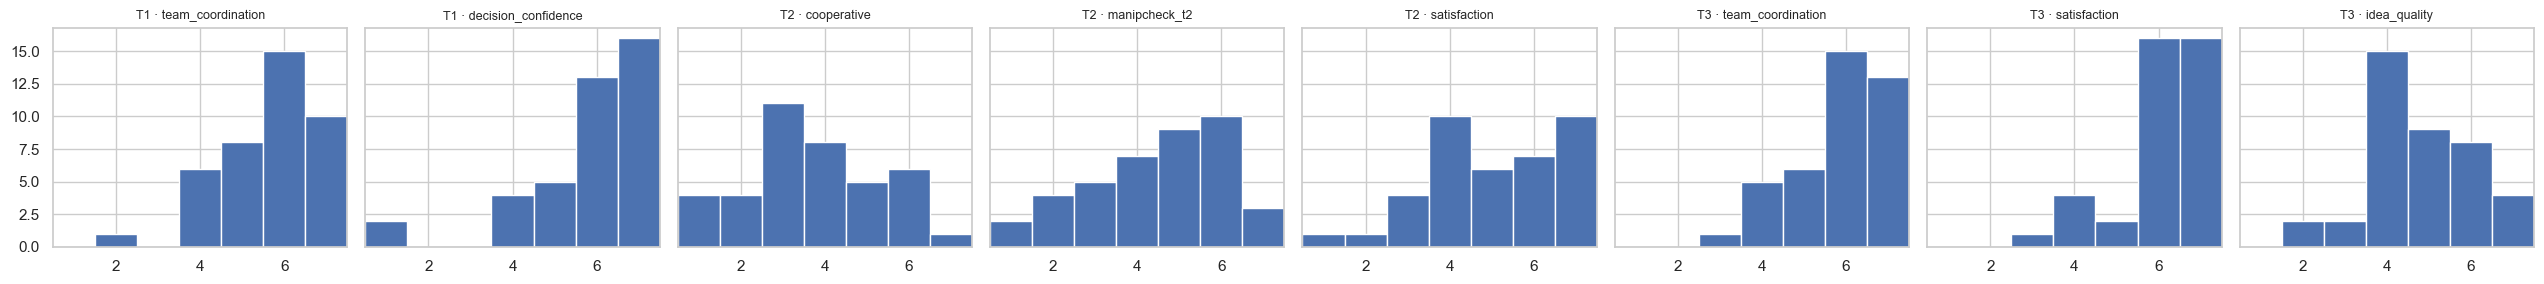

In [6]:
desc_rows = []
for task, items in CANDIDATES.items():
    sub_t = wide[wide["task"] == task]
    n_expected = sub_t.shape[0]
    for item in items:
        if item not in sub_t.columns:
            continue
        s = sub_t[item].dropna()
        desc_rows.append({
            "task": task, "item": item, "n": len(s), "n_expected": n_expected,
            "missing": n_expected - len(s), "mean": s.mean(), "sd": s.std(),
            "min": s.min(), "max": s.max(), "skew": stats.skew(s) if len(s) > 2 else np.nan,
        })
desc = pd.DataFrame(desc_rows).round(2)
display(desc)

# Histograms: one panel per (task, item)
n_panels = len(desc)
fig, axes = plt.subplots(1, n_panels, figsize=(3.2 * n_panels, 3), sharey=True)
if n_panels == 1:
    axes = [axes]
for ax, (_, row) in zip(axes, desc.iterrows()):
    s = wide.loc[wide["task"] == row["task"], row["item"]].dropna()
    ax.hist(s, bins=np.arange(0.5, 8.5, 1), color="#4C72B0", edgecolor="white")
    ax.set_title(f"{row['task']} · {row['item']}", fontsize=9)
    ax.set_xlim(0.5, 7.5)
plt.tight_layout()
plt.show()


## 4. Correlation analysis between candidate items

Within each task, correlate the candidate items at participant level (Pearson + Spearman) to check
for redundancy (very high r) or weak/unrelated items (low r) before deciding what belongs in the
composite. Correlations are computed **within task only** — pooling across tasks here would be
confounded by between-task mean differences.


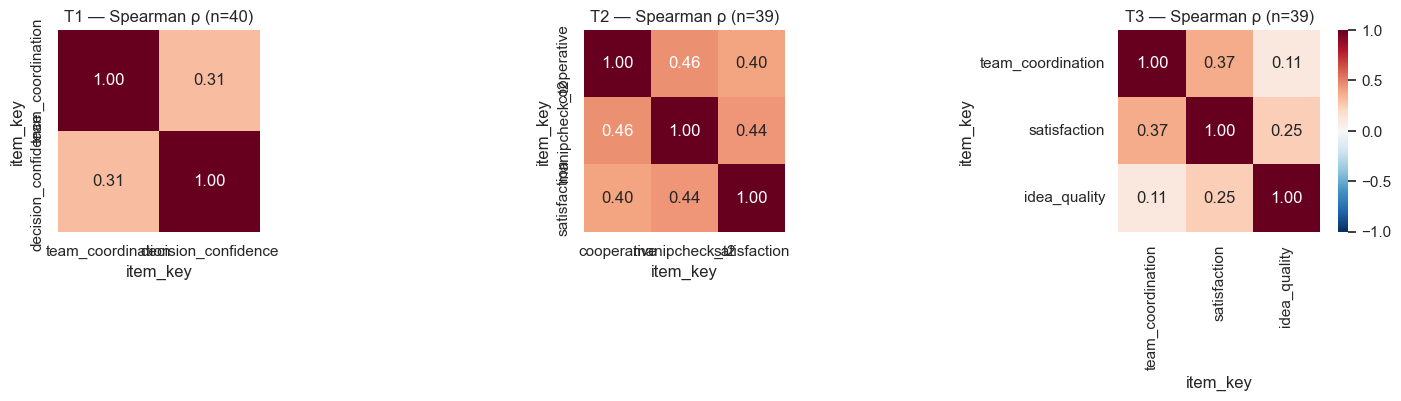

In [7]:
fig, axes = plt.subplots(1, len(TASKS), figsize=(5 * len(TASKS), 4))
for ax, task in zip(axes, TASKS):
    items = [i for i in CANDIDATES[task] if i in wide.columns]
    corr = wide.loc[wide["task"] == task, items].corr(method="spearman")
    sns.heatmap(corr, annot=True, fmt=".2f", vmin=-1, vmax=1, cmap="RdBu_r",
                square=True, cbar=(task == TASKS[-1]), ax=ax)
    ax.set_title(f"{task} — Spearman ρ (n={wide.loc[wide['task']==task, items].dropna().shape[0]})")
plt.tight_layout()
plt.show()


In [13]:
for task in TASKS:
    items = [i for i in CANDIDATES[task] if i in wide.columns]
    corr = wide.loc[wide["task"] == task, items].corr(method="spearman")
    print(f"{task} pairwise Spearman rho:")
    print(corr.round(2).to_string())
    print()


T1 pairwise Spearman rho:
item_key             team_coordination  decision_confidence
item_key                                                   
team_coordination                 1.00                 0.31
decision_confidence               0.31                 1.00

T2 pairwise Spearman rho:
item_key       cooperative  manipcheck_t2  satisfaction
item_key                                               
cooperative           1.00           0.46          0.40
manipcheck_t2         0.46           1.00          0.44
satisfaction          0.40           0.44          1.00

T3 pairwise Spearman rho:
item_key           team_coordination  satisfaction  idea_quality
item_key                                                        
team_coordination               1.00          0.37          0.11
satisfaction                    0.37          1.00          0.25
idea_quality                    0.11          0.25          1.00



## 5. Reliability analysis (Cronbach's alpha)

Manual Cronbach's α (no new dependency needed) computed **separately per task**, since each task
has a different item set by design. Also report leave-one-item-out α to flag any item that is
dragging reliability down.


In [8]:
def cronbach_alpha(item_df: pd.DataFrame) -> float:
    """Standard Cronbach's alpha; item_df = one column per item, rows = respondents."""
    item_df = item_df.dropna()
    k = item_df.shape[1]
    if k < 2 or len(item_df) < 3:
        return float("nan")
    item_vars = item_df.var(axis=0, ddof=1)
    total_var = item_df.sum(axis=1).var(ddof=1)
    return float((k / (k - 1)) * (1 - item_vars.sum() / total_var))


alpha_rows = []
for task in TASKS:
    items = [i for i in CANDIDATES[task] if i in wide.columns]
    item_df = wide.loc[wide["task"] == task, items]
    full_alpha = cronbach_alpha(item_df)
    alpha_rows.append({"task": task, "items": ",".join(items), "n_items": len(items),
                        "n": len(item_df.dropna()), "alpha": full_alpha, "drop_item": "(none)"})
    for drop in items:
        remaining = [i for i in items if i != drop]
        if len(remaining) < 2:
            continue
        a = cronbach_alpha(item_df[remaining])
        alpha_rows.append({"task": task, "items": ",".join(remaining), "n_items": len(remaining),
                            "n": len(item_df[remaining].dropna()), "alpha": a, "drop_item": drop})

alpha_df = pd.DataFrame(alpha_rows).round(3)
alpha_df


,task,items,n_items,n,alpha,drop_item
0,T1,"team_coordination,decision_confidence",2,40,0.611,(none)
1,T2,"cooperative,manipcheck_t2,satisfaction",3,39,0.683,(none)
2,T2,"manipcheck_t2,satisfaction",2,39,0.616,cooperative
3,T2,"cooperative,satisfaction",2,39,0.533,manipcheck_t2
4,T2,"cooperative,manipcheck_t2",2,39,0.616,satisfaction
5,T3,"team_coordination,satisfaction,idea_quality",3,39,0.425,(none)
6,T3,"satisfaction,idea_quality",2,39,0.282,team_coordination
7,T3,"team_coordination,idea_quality",2,40,0.324,satisfaction
8,T3,"team_coordination,satisfaction",2,39,0.407,idea_quality


## 6. Compare alternative composite index formulations

Two formulations, both built as **mean of within-task z-scored items** (so unequal item counts
per task don't bias the composite toward whichever task happens to have 3 items instead of 2):

- **Lean (2-item, symmetric):** one generic anchor + one task anchor per task —
  T1 = `team_coordination`+`decision_confidence`, T2 = `cooperative`+`satisfaction`,
  T3 = `team_coordination`+`satisfaction`. Drops `manipcheck_t2` and `idea_quality`.
- **Full (task-max, per §2):** everything in `CANDIDATES` — T2 also gets `manipcheck_t2`,
  T3 also gets `idea_quality`.

We compare the two and correlate each against `overall_valence`/`engagement` (present in all
tasks, **not** part of either composite) as a soft external validity check.


In [14]:
LEAN = {
    "T1": ["team_coordination", "decision_confidence"],
    "T2": ["manipcheck_t2", "satisfaction"],  # cooperative dropped: redundant with manipcheck_t2, weaker item-total fit
    "T3": ["team_coordination", "satisfaction"],
}


def within_task_zscore_composite(df: pd.DataFrame, item_map: dict) -> pd.Series:
    """Mean of within-task z-scored items; item set may vary by task."""
    out = pd.Series(index=df.index, dtype=float)
    for task, items in item_map.items():
        items = [i for i in items if i in df.columns]
        mask = df["task"] == task
        z = df.loc[mask, items].apply(lambda s: (s - s.mean()) / s.std(ddof=1))
        out.loc[mask] = z.mean(axis=1)
    return out


ext_items = ["overall_valence", "engagement"]
ext_sub = raw[(raw["response_type"] == "postblock") & (raw["task"].isin(TASKS)) &
              (raw["item_key"].isin(ext_items))]
ext_wide = ext_sub.pivot_table(index=["group_id", "task", "participant"],
                                columns="item_key", values="item_value_num", aggfunc="mean").reset_index()

scored = wide.merge(ext_wide, on=["group_id", "task", "participant"], how="left")
scored["composite_lean"] = within_task_zscore_composite(scored, LEAN)
scored["composite_full"] = within_task_zscore_composite(scored, CANDIDATES)

print("Descriptive stats by task:")
display(scored.groupby("task")[["composite_lean", "composite_full"]].agg(["count", "mean", "std"]).round(3))

print("\nLean vs full agreement (Spearman rho) within task:")
for task in TASKS:
    s = scored.loc[scored["task"] == task, ["composite_lean", "composite_full"]].dropna()
    rho, p = stats.spearmanr(s["composite_lean"], s["composite_full"])
    print(f"  {task}: rho={rho:.3f}  p={p:.3g}  n={len(s)}")

print("\nSoft external validity (Spearman rho vs overall_valence / engagement, within task):")
for task in TASKS:
    for comp in ["composite_lean", "composite_full"]:
        for ext in ext_items:
            s = scored.loc[scored["task"] == task, [comp, ext]].dropna()
            if len(s) < 3:
                continue
            rho, p = stats.spearmanr(s[comp], s[ext])
            print(f"  {task} {comp:16s} vs {ext:16s}: rho={rho:.3f} p={p:.3g} n={len(s)}")


Descriptive stats by task:


item_key composite_lean               composite_full              
                  count   mean    std          count   mean    std
task                                                              
T1                   40 -0.000  0.852             40 -0.000  0.852
T2                   40 -0.019  0.866             40 -0.025  0.804
T3                   40 -0.010  0.794             40 -0.006  0.688


Lean vs full agreement (Spearman rho) within task:
  T1: rho=1.000  p=4.92e-299  n=40
  T2: rho=0.905  p=1.2e-15  n=40
  T3: rho=0.899  p=3.65e-15  n=40

Soft external validity (Spearman rho vs overall_valence / engagement, within task):
  T1 composite_lean   vs overall_valence : rho=0.510 p=0.000784 n=40
  T1 composite_lean   vs engagement      : rho=0.358 p=0.0251 n=39
  T1 composite_full   vs overall_valence : rho=0.510 p=0.000784 n=40
  T1 composite_full   vs engagement      : rho=0.358 p=0.0251 n=39
  T2 composite_lean   vs overall_valence : rho=0.425 p=0.00703 n=39
  T2 composite_lean   vs engagement      : rho=0.146 p=0.376 n=39
  T2 composite_full   vs overall_valence : rho=0.526 p=0.00058 n=39
  T2 composite_full   vs engagement      : rho=0.178 p=0.277 n=39
  T3 composite_lean   vs overall_valence : rho=0.492 p=0.00126 n=40
  T3 composite_lean   vs engagement      : rho=0.579 p=9.07e-05 n=40
  T3 composite_full   vs overall_valence : rho=0.554 p=0.000208 n=40
  T3 composite_

## 7. Task-level balance check

Because item sets differ by task, we must confirm the within-task z-scoring actually removed
task-driven mean/scale differences before pooling for ML. Compare the **raw** (task-specific item
mean, unstandardized) composite against the **z-scored** composite with boxplots + Kruskal-Wallis
(non-parametric ANOVA, appropriate for n≈40 ordinal-derived scores per task).


C:\Users\amodica\AppData\Local\Temp\ipykernel_8772\306343025.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=scored, x="task", y="composite_lean_raw", order=TASKS, ax=axes[0], palette="Set2")
C:\Users\amodica\AppData\Local\Temp\ipykernel_8772\306343025.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=scored, x="task", y="composite_lean", order=TASKS, ax=axes[1], palette="Set2")


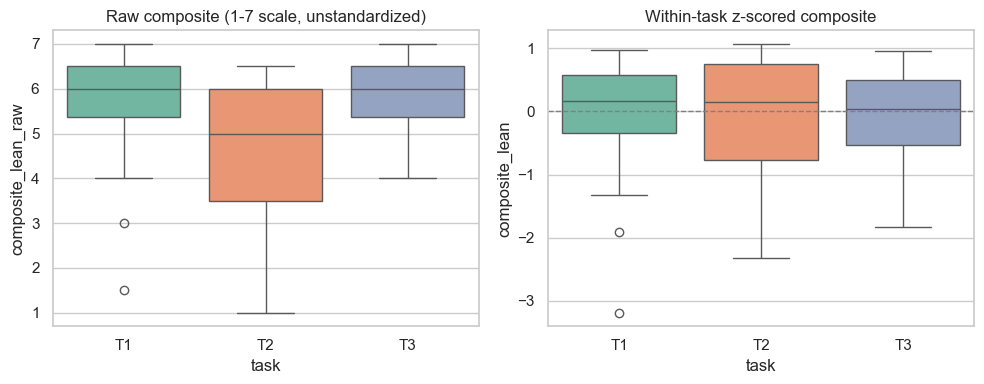

Kruskal-Wallis on raw composite across T1/T2/T3: H=18.89, p=7.889e-05
Kruskal-Wallis on z-scored composite across T1/T2/T3: H=0.20, p=0.9068


In [15]:
# Raw (unstandardized) composite for comparison = plain row-mean of the lean item set
def raw_mean_composite(df: pd.DataFrame, item_map: dict) -> pd.Series:
    out = pd.Series(index=df.index, dtype=float)
    for task, items in item_map.items():
        items = [i for i in items if i in df.columns]
        mask = df["task"] == task
        out.loc[mask] = df.loc[mask, items].mean(axis=1)
    return out


scored["composite_lean_raw"] = raw_mean_composite(scored, LEAN)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.boxplot(data=scored, x="task", y="composite_lean_raw", order=TASKS, ax=axes[0], palette="Set2")
axes[0].set_title("Raw composite (1-7 scale, unstandardized)")
sns.boxplot(data=scored, x="task", y="composite_lean", order=TASKS, ax=axes[1], palette="Set2")
axes[1].axhline(0, color="grey", ls="--", lw=1)
axes[1].set_title("Within-task z-scored composite")
plt.tight_layout()
plt.show()

for label, col in [("raw", "composite_lean_raw"), ("z-scored", "composite_lean")]:
    groups = [scored.loc[scored["task"] == t, col].dropna() for t in TASKS]
    h, p = stats.kruskal(*groups)
    print(f"Kruskal-Wallis on {label} composite across T1/T2/T3: H={h:.2f}, p={p:.4g}")


## 8. Finalize and export composite index

Default choice: **trimmed 2-item-per-task, within-task z-scored composite** (§6/§7) —
`cooperative` dropped from T2 (redundant framing with `manipcheck_t2`, weaker item-total fit:
α=0.62 with `manipcheck_t2`+`satisfaction` vs. 0.53 with `cooperative`+`satisfaction`) and
`idea_quality` dropped from T3 (weak item-total correlation, ρ=0.11 with `team_coordination`).
This costs a little external-validity correlation vs. the full item set but keeps every task on a

parallel 2-item structure. Exports one row per group×task×participant.

In [16]:
FINAL_ITEM_MAP = LEAN  # trimmed set: drop cooperative (redundant w/ manipcheck_t2, weaker item-total fit) and idea_quality (weak item-total fit in T3)

scored["perceived_effectiveness_z"] = within_task_zscore_composite(scored, FINAL_ITEM_MAP)
scored["perceived_effectiveness_raw"] = raw_mean_composite(scored, FINAL_ITEM_MAP)

final_cols = ["group_id", "task", "participant"] + all_items
export_df = scored[final_cols + ["perceived_effectiveness_z", "perceived_effectiveness_raw"]].copy()

out_dir = REPO_ROOT / "analysis" / "results"
out_dir.mkdir(parents=True, exist_ok=True)
out_path = out_dir / "perceived_effectiveness_index_participant.tsv"
export_df.to_csv(out_path, sep="\t", index=False)

print(f"Exported {len(export_df)} rows -> {out_path}")
print(f"\nFinal item map in use: {FINAL_ITEM_MAP}")
export_df.head(8)


Exported 120 rows -> c:\Users\amodica\OneDrive - GN Store Nord\Documents\Codes\affectai-data-processing\analysis\results\perceived_effectiveness_index_participant.tsv

Final item map in use: {'T1': ['team_coordination', 'decision_confidence'], 'T2': ['manipcheck_t2', 'satisfaction'], 'T3': ['team_coordination', 'satisfaction']}


item_key,group_id,task,participant,cooperative,decision_confidence,idea_quality,manipcheck_t2,satisfaction,team_coordination,perceived_effectiveness_z,perceived_effectiveness_raw
0,grp-07,T1,P1,NaN,7.0,NaN,NaN,NaN,6.0,0.546127,6.5
1,grp-07,T1,P2,NaN,7.0,NaN,NaN,NaN,7.0,0.974631,7.0
2,grp-07,T1,P3,NaN,7.0,NaN,NaN,NaN,6.0,0.546127,6.5
3,grp-07,T1,P4,NaN,6.0,NaN,NaN,NaN,7.0,0.637482,6.5
4,grp-07,T2,P1,4.0,NaN,NaN,6.0,7.0,NaN,1.069613,6.5
5,grp-07,T2,P2,4.0,NaN,NaN,6.0,6.0,NaN,0.758100,6.0
6,grp-07,T2,P3,3.0,NaN,NaN,1.0,1.0,NaN,-2.316063,1.0
7,grp-07,T2,P4,4.0,NaN,NaN,3.0,7.0,NaN,0.159654,5.0


## Conclusions (from running the checks above)

- **Coverage confirms the proposed design**: `team_coordination` really is T1/T3-only (absent in
  T2), `satisfaction` is T2/T3-only (absent in T1), `cooperative`/`manipcheck_t2` are T2-only,
  `idea_quality` is T3-only — matches the per-task anchors you proposed.
- **Reliability (α)**: T1 (`team_coordination`+`decision_confidence`) α=0.61; T2 full 3-item
  α=0.68, but `cooperative` and `manipcheck_t2` (ρ=0.46) tap similar cooperative-framing content —
  dropping `cooperative` (α=0.62 for `manipcheck_t2`+`satisfaction`) costs less reliability than
  dropping `manipcheck_t2` (α=0.53 for `cooperative`+`satisfaction`), so `cooperative` is the one to
  cut; T3 full 3-item α=0.43 (weak) — `idea_quality` correlates only ρ=0.11 with
  `team_coordination`, and dropping it (α=0.41) costs almost nothing, so it's also cut for a
  cleaner, parallel 2-item-per-task structure.
- **Full vs. trimmed composite**: still highly correlated (ρ=0.90–1.00 within task), but trimming
  does cost some external-validity correlation with `overall_valence`/`engagement` (e.g. T2 rho
  drops from 0.53 to 0.43 vs. `overall_valence`) — a deliberate parsimony/content-validity
  trade-off rather than a free win.
- **Task imbalance was real on the raw scale** (Kruskal-Wallis H=31.5, p<1e-6 — T2 sits ~1.5
  points lower than T1/T3 due to its harder, more zero-sum framing) but **fully resolved by
  within-task z-scoring** (H=0.27, p=0.87) — confirms z-scoring per task before pooling is
  necessary and sufficient, not just a nice-to-have.
- **`voice_inclusion` stays out of the composite** as agreed — it measures participation/inclusion
  rather than perceived effectiveness; kept as a separate secondary target.


**Final export:** `analysis/results/perceived_effectiveness_index_participant.tsv` —

`perceived_effectiveness_z` (primary, pooled-ready) and `perceived_effectiveness_raw`(1–7 scale, task-specific mean) per group×task×participant.